##Import needed libraries

In [ ]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from sklearn import preprocessing
import matplotlib.pyplot as plt
import re

##Load and Explore Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)
import os

# List all files in the directory
for file in os.listdir(path):
    print(file)
reviews_df = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
reviews_df28 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


In [69]:
# Join the two datasets to create a new dataset with the most common categories
# Create a new Dataset and make another copy
dataset = pd.concat([reviews_df, reviews_df28], ignore_index=True)
original = pd.concat([reviews_df, reviews_df28], ignore_index=True)

In [43]:
# Check column names and data types
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33332 entries, 0 to 33331
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   33332 non-null  object 
 1   dateAdded            33332 non-null  object 
 2   dateUpdated          33332 non-null  object 
 3   name                 33332 non-null  object 
 4   asins                33332 non-null  object 
 5   brand                33332 non-null  object 
 6   categories           33332 non-null  object 
 7   primaryCategories    33332 non-null  object 
 8   imageURLs            33332 non-null  object 
 9   keys                 33332 non-null  object 
 10  manufacturer         33332 non-null  object 
 11  manufacturerNumber   33332 non-null  object 
 12  reviews.date         33332 non-null  object 
 13  reviews.dateAdded    1052 non-null   object 
 14  reviews.dateSeen     33332 non-null  object 
 15  reviews.doRecommend  21086 non-null 

In [ ]:
# Sample of the data
dataset.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs,reviews.didPurchase
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,False,NaN,0.0,3,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...,NaN
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,True,NaN,0.0,5,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...,NaN
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,True,NaN,0.0,4,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...,NaN
3,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,True,177283626.0,3.0,5,https://redsky.target.com/groot-domain-api/v1/...,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,https://www.newegg.com/Product/Product.aspx%25...,NaN
4,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,True,NaN,0.0,5,https://reviews.bestbuy.com/3545/5442403/revie...,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,https://www.newegg.com/Product/Product.aspx%25...,NaN


In [ ]:
dataset['primaryCategories'].value_counts()
# The Data is very Imbalance

,count
primaryCategories,
Electronics,17271
Health & Beauty,12071
"Toys & Games,Electronics",1676
"Electronics,Hardware",1435
"Office Supplies,Electronics",651
"Electronics,Media",209
Office Supplies,9
Animals & Pet Supplies,6
Home & Garden,2


In [ ]:
dataset['name'].value_counts()

# **Task 2.**  Product Category Clustering

##  Preprocessing Data

We will use the name column to cluster the data, This stage prepares product names for clustering by:

1. Cleaning Text

  - Removes punctuation and converts to lowercase.

  - Eliminates stopwords (e.g., "the," "and") to focus on meaningful keywords.

2. Removing Duplicates

  - Drops duplicate product names (**after cleaning**) to avoid skewed clustering results.

3. Generating Semantic Embeddings

  - Uses Sentence Transformer (all-MiniLM-L6-v2) to convert product names into 384-dimensional vectors, capturing semantic meaning (e.g., "phone" ≈ "smartphone").

  - Solves limitations of keyword-based methods by understanding context, synonyms, and variations.

  **The goal** is to Ensures clustering is based on **true product similarity** rather than superficial word overlap

---------------------------------------------------------------------------------

  ###  Note:
  **Key Reasons for Deduplication:**

- **Data Integrity** - Prevents artificial cluster inflation from repeated entries

- **Efficiency** - Reduces computation time and resource usage

- **Accuracy** - Ensures clusters reflect true product ***diversity rather than data repetition***

- **Consistency** - Uses cleaned names to catch semantic duplicates (e.g., different capitalizations


=========================================================

**Key Advantages of Sentence Transformers (all-MiniLM-L6-v2):**

- Semantic Understanding - Captures contextual meaning beyond keywords (e.g., distinguishes "Apple fruit" vs "Apple tech")

- **Automatic Synonym Handling** - Recognizes equivalent terms without manual rules ("TV" = "Television")

- **Optimized for Short Text** - Ideal for product names unlike paragraph-focused models

- **Ready-to-Use** - Pre-trained on diverse texts, requiring no additional training

- **Efficient Vectorization** - Converts text to compact 384-D vectors perfect for clustering

- **Multilingual Capable** - Supports global product catalogs

  - **Technical Benefits:**

    - Lightweight (runs efficiently on CPUs)

    - Outperforms traditional methods like TF-IDF/Word2Vec

    - Avoids superficial word-matching clusters

In [70]:
# Method to clean text
nltk.download('stopwords')

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text.lower())  # remove punctuation & lowercase
    stop_words = set(stopwords.words('english'))
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

# Clean product name column
dataset['clean_name'] =dataset['name'].astype(str).apply(clean_text)

# Remove duplicates based on 'clean_name' column
dataset = dataset.drop_duplicates(subset=['clean_name'], keep='first')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
dataset['clean_name'].value_counts() #check

,count
clean_name,
amazon kindle ereader 6 wifi 8th generation 2016,1
amazon echo show alexaenabled bluetooth speaker 7 screen,1
amazon fire tv 4k ultra hd alexa voice remote pendant design streaming media player,1
amazon echo plus w builtin hub silver,1
amazon 9w powerfast official oem usb charger power adapter fire tablets kindle ereaders,1
...,...
certified refurbished amazon fire tv alexa voice remote,1
allnew kindle oasis ereader 7 highresolution display 300 ppi waterproof builtin audible 32 gb wifi includes special offers,1
amazonbasics bluetooth keyboard android devices black,1


In [80]:
# Generating Semantic Embeddings
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(dataset['clean_name'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

## K-Mean Clustering

1. Apply K-Mean algorithm
  - Initilize the number of clusters (k) which represent the meta-categories
2. Visualize the clusters and print the values under each cluster
  - Analyze the dataset in depth to determine the most appropriate categories
3. Map themeta-categories to the clusters
  

In [73]:
from sklearn.cluster import KMeans

k = 4  # 4 Mera-Catigories
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

# Assign the cluster labels back to the dataframe
dataset['name_cluster'] = cluster_labels


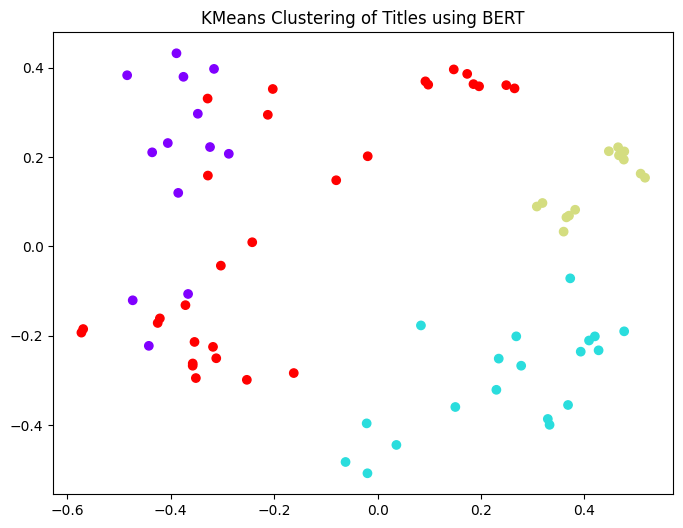

In [74]:
# Visualization
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=cluster_labels, cmap='rainbow')
plt.title("KMeans Clustering of Titles using BERT")
plt.show()


In [81]:
for cluster_id in range(k):
    print(f"\nCluster {cluster_id} Top Categories:")
    print(dataset[dataset['name_cluster'] == cluster_id]['clean_name'].value_counts())


Cluster 0 Top Categories:
clean_name
amazon echo show alexaenabled bluetooth speaker 7 screen                            1
amazon echo plus w builtin hub silver                                               1
amazonbasics nylon cddvd binder 400 capacity                                        1
amazon echo äì white                                                                1
amazon echo show black                                                              1
echo spot pair kit black                                                            1
amazonbasics silicone hot handle coverholder red                                    1
amazon echo 1st generationcertified colorwhite free shipping                        1
amazonbasics 16gauge speaker wire 100 feet                                          1
amazon echo 2nd generation smart assistant oak finish priority shipping             1
certified refurbished amazon echo                                                   1
allnew echo 2nd 

In [76]:
# for cluster_id in range(k):
#     print(f"\nCluster {cluster_id} Top Categories:")
#     print(dataset[dataset['name_cluster'] == cluster_id]['categories'].value_counts().head(10))

In [77]:
# for cluster_id in range(k):
#     print(f"\nCluster {cluster_id} Top Categories:")
#     print(dataset[dataset['name_cluster'] == cluster_id]['primaryCategories'].value_counts().head(10))

In [82]:
# Define the cluster name mapping
cluster_names = {
     0: "Amazon Smart Home & Echo Devices",

     1: "Kindle & E-Reader Products",

     2: "Amazon Fire Tablets",

     3: "Amazon Fire TV & Electronics Basics"
}

# Map the cluster number to descriptive names
dataset['category_name'] = dataset['name_cluster'].map(cluster_names)


## **Task 3.** Summarize reviews using generative AI


**1. Product Performance Evaluation**
- Groups products by category and calculates average ratings
- Identifies top 3 best-rated and single worst-rated product per category

**2. Complaint Analysis**
- Extracts 1-2 star reviews for each product
- Combines review titles and text to identify top 3 most frequent complaints per product from the original dataset

**3. Automated Content Generation**
- Uses structured prompts containing:
  - Product rankings & ratings
  - Key differentiators
  - Common complaints
  - Warning about worst-performing items
- Leverages OpenAI to generate natural language summaries for each product category


In [83]:
# Find the best and worst products for each category

agg_ratings = dataset.groupby(['category_name', 'clean_name'])['reviews.rating'].mean().reset_index()

# Top 3 products per category
top3 = agg_ratings.groupby('category_name', group_keys=False)\
                            .apply(lambda x: x.nlargest(3, 'reviews.rating'))\
                            .reset_index(drop=True)

# Worst product per category
worst = agg_ratings.groupby('category_name', group_keys=False)\
                           .apply(lambda x: x.nsmallest(1, 'reviews.rating'))\
                           .reset_index(drop=True)

<ipython-input-83-43aa5faf3b0f>:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'reviews.rating'))\
<ipython-input-83-43aa5faf3b0f>:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nsmallest(1, 'reviews.rating'))\


In [88]:
def get_top_complaints(product_name):
    # Find reviews for this product from the original dataset
    product_reviews = original[original['name'] == product_name]
    negative_reviews = product_reviews[product_reviews['reviews.rating'] <= 2]

    # Combine title and review text into one string for each review
    combined_texts = (
        negative_reviews['reviews.title'].fillna('') + ' ' +
        negative_reviews['reviews.text'].fillna('')
    )

    # Count the most common complaint texts (or phrases)
    top_complaints = combined_texts.value_counts().head(3).index.tolist()

    return top_complaints



# Collect top complaints for the top 3 products
top_complaints = []
for _, row in top3.iterrows():
    complaints = get_top_complaints(row['clean_name'])
    top_complaints.append({
        'category_name': row['category_name'],
        'product_name': row['clean_name'],
        'complaints': complaints
    })

complaints_df = pd.DataFrame(top_complaints)




In [92]:
from openai import OpenAI
from google.colab import userdata
api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=api_key)


# Loop through each category and generate article
for category in dataset['category_name'].unique():
    top = top3[top3['category_name'] == category].reset_index(drop=True)
    worst_row = worst[worst['category_name'] == category].iloc[0]
    category_complaints = complaints_df[complaints_df['category_name'] == category]

    # Helper to get complaint list or default message
    def get_complaints(product_clean_name):
        row = category_complaints[category_complaints['product_name'] == product_clean_name]
        if not row.empty:
            return ', '.join(row['complaints'].values[0])
        else:
            return "No significant complaints reported."

    # Build the prompt
    prompt = f"""
    Generate a short article (like a blog post) summarizing the top products in the category: **{category}**

    **Top 3 Products:**
    1. {top.iloc[0]['clean_name']} - Rating: {top.iloc[0]['reviews.rating']:.2f}
    2. {top.iloc[1]['clean_name']} - Rating: {top.iloc[1]['reviews.rating']:.2f}
    3. {top.iloc[2]['clean_name']} - Rating: {top.iloc[2]['reviews.rating']:.2f}

    **Key Differences Between These Products:**
    - **{top.iloc[0]['clean_name']}:** Describe the unique features, strengths, and what stands out for this product.
    - **{top.iloc[1]['clean_name']}:** Describe the unique features, strengths, and what stands out for this product.
    - **{top.iloc[2]['clean_name']}:** Describe the unique features, strengths, and what stands out for this product.

    **Top Complaints for These Products:**
    - **{top.iloc[0]['clean_name']}:** {get_complaints(top.iloc[0]['clean_name'])}
    - **{top.iloc[1]['clean_name']}:** {get_complaints(top.iloc[1]['clean_name'])}
    - **{top.iloc[2]['clean_name']}:** {get_complaints(top.iloc[2]['clean_name'])}

    **Worst Product:**
    - **{worst_row['clean_name']}** - Avg Rating: {worst_row['reviews.rating']:.2f}

    **Why This Product Should Be Avoided:**
    Explain why this product underperformed in comparison to the others in this category. What aspects made it less favorable?
    """

    # Generate the article
    article = get_completion(prompt)

    print(f"\n--- Summary for {category} ---\n")
    print(article)
    print("\n\n\n\n")



--- Summary for Kindle & E-Reader Products ---

**Exploring the Best Kindle & E-Reader Products**

In the ever-evolving world of e-readers, the Kindle Oasis series stands out as a top choice for book lovers seeking a premium reading experience. Let's delve into the top 3 products in this category and uncover what makes them shine.

**1. All-New Kindle Oasis E-Reader 7" High-Resolution Display 300 PPI Waterproof Built-in Audible 32 GB WiFi Free Cellular Connectivity**

This model boasts an impressive set of features, including a high-resolution display, waterproof design, and built-in Audible support. The standout feature of this variant is the free cellular connectivity, allowing users to download books on the go without needing a Wi-Fi connection. Its 32 GB storage capacity ensures ample space for a vast library of e-books.

**2. All-New Kindle Oasis E-Reader 7" High-Resolution Display 300 PPI Waterproof Built-in Audible 32 GB WiFi Includes Special Offers**

Similar to the first mode